In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [122]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree

iris = load_iris(as_frame = True)

In [ ]:
print(iris.DESCR)

In [51]:
iris.data.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [52]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

Separando os dados e os alvos

In [123]:
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target

In [99]:
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Sklearn utiliza o algoritmo CART, o qual produz arvores de decisao do tipo binaria. Cada node produz duas divisões.

Outros algoritmos como ID3 fazem arvores com maior numero de divisões por no

[Text(0.4, 0.8333333333333334, 'petal length (cm) <= 2.45\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]\nclass = setosa'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]\nclass = setosa'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'petal width (cm) <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]\nclass = versicolor'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.168\nsamples = 54\nvalue = [0, 49, 5]\nclass = versicolor'),
 Text(0.8, 0.16666666666666666, 'gini = 0.043\nsamples = 46\nvalue = [0, 1, 45]\nclass = virginica')]

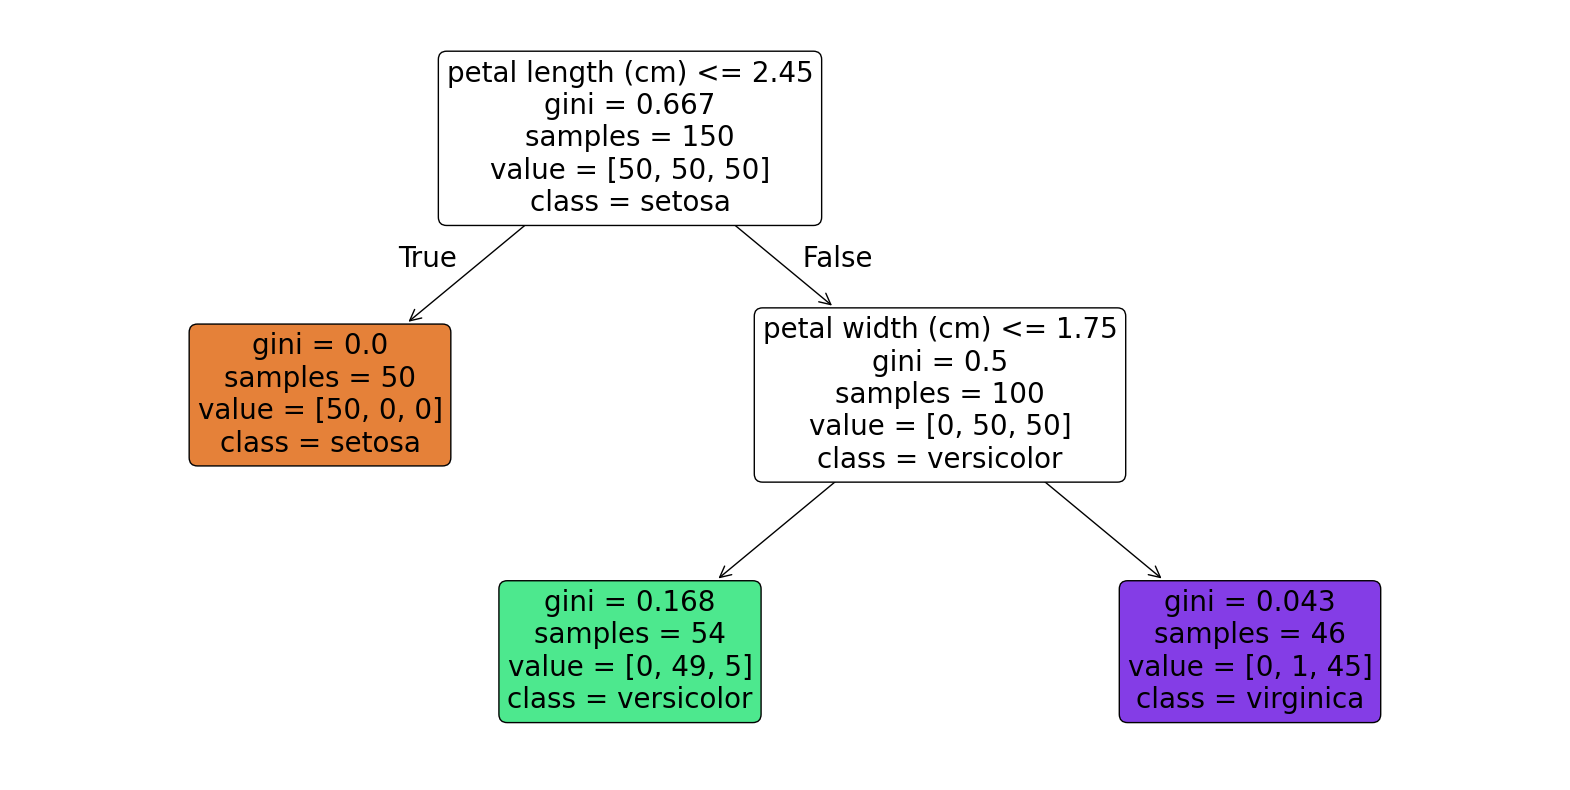

In [124]:
plt.figure(figsize=(20,10))
plot_tree(tree_clf,
          feature_names=["petal length (cm)", "petal width (cm)"],
          class_names=iris.target_names,
          rounded=True,
          fontsize=20,
          filled=True)

Gini é um indice de impureza, calcula 1 menos a probabilidade de cada instancia na classe, se zero a classificação é perfeita no nó:

$${G = 1 - \sum p_i ^ 2}$$

* Leaf Node Setosa: ${G = 1 - (\frac{50}{50})^2 - (\frac{0}{50})^2 - (\frac{0}{50})^2 = 0}$


* Leaf Node Versicolo: ${G = 1 - (\frac{0}{54})^2 - (\frac{49}{54})^2 - (\frac{5}{54})^2 = 0.168}$


* Leaf Node Virginica: ${G = 1 - (\frac{0}{46})^2 - (\frac{1}{46})^2 - (\frac{45}{46})^2 = 0.043}$

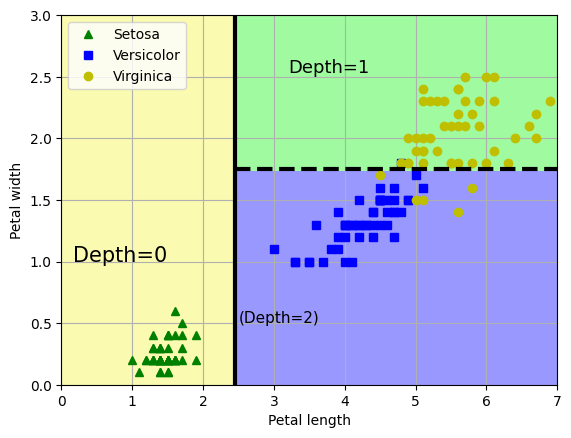

In [128]:
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])

X_setosa = X_iris[y == 0]
X_versicolor = X_iris[y == 1]
X_virginica = X_iris[y == 2]

plt.plot(X_setosa[:,0],X_setosa[:,1], 'g^', label='Setosa')
plt.plot(X_versicolor[:,0],X_versicolor[:,1], 'bs', label='Versicolor')
plt.plot(X_virginica[:,0],X_virginica[:,1], 'yo', label='Virginica')
plt.plot([2.45,2.45], [0,3], 'k-', linewidth=3)
plt.plot([2.45,7], [1.75,1.75], 'k--', linewidth=3)
plt.grid()
plt.legend()
plt.xlabel("Petal length")
plt.ylabel("Petal width")

x0s = np.linspace(0,7, 100)
x1s = np.linspace(0, 3, 100)
x0, x1 = np.meshgrid(x0s, x1s)
X_grid = np.c_[x0.ravel(), x1.ravel()]

y_pred = tree_clf.predict(X_grid)
plt.contourf(x0,x1,y_pred.reshape(x0.shape), cmap=custom_cmap)

plt.text( 1.5, 1.0, "Depth=0", horizontalalignment="right", fontsize=15)
plt.text(3.2,  2.5, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.text( 2.5, 0.5, "(Depth=2)", fontsize=11)

plt.show()